# 1. Carga inicial y visión general

Este capítulo corresponde a la sección 9.10.4.1.1 del enunciado. Se lee el archivo
`accepted_2007_to_2018Q4.csv.gz` completo (Kaggle, *wordsforthewise/lending-club*), se verifica
la lectura, se describe su estructura y se define la población de préstamos sobre la que se
construye la variable objetivo `default`. La lectura se hace con pandas y, para comparar tiempos,
también con Spark.

In [1]:
import os
import sys
import time
import warnings

sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import utils as u

u.estilo()
pd.set_option("display.max_columns", 40, "display.width", 180, "display.max_colwidth", 40)
print("Equipo utilizado:")
for k, v in u.hardware().items():
    print(f"  {k}: {v}")

Equipo utilizado:
  sistema: Darwin 27.0.0
  python: 3.11.16
  nucleos_logicos: 10
  cpu: Apple M5
  nucleos_rendimiento: 4
  nucleos_eficiencia: 6
  ram_gb: 24.0


## 1.1 Lectura del CSV completo con pandas

Se lee el archivo comprimido completo, sin muestreo ni `nrows`.

In [2]:
t0 = time.time()
crudo = pd.read_csv(u.CSV_CRUDO, low_memory=False)
t_pandas = time.time() - t0
print(f"Tamaño del archivo comprimido: {u.CSV_CRUDO.stat().st_size / 2**20:.0f} MB")
print(f"Tiempo de lectura con pandas: {t_pandas:.1f} s")
print(f"Dimensión del archivo: {crudo.shape[0]:,} filas x {crudo.shape[1]} columnas")
print(f"Memoria en pandas: {crudo.memory_usage(deep=True).sum() / 2**30:.2f} GB")

Tamaño del archivo comprimido: 374 MB
Tiempo de lectura con pandas: 26.9 s
Dimensión del archivo: 2,260,701 filas x 151 columnas


Memoria en pandas: 6.26 GB


## 1.2 Primeras y últimas filas

In [3]:
crudo.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,...,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanD...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanD...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanD...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.0,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanD...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanD...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
crudo.tail()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,...,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,Vice President,9 years,MORTGAGE,227000.0,Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanD...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,Program Manager,6 years,RENT,110000.0,Not Verified,Oct-2016,Charged Off,n,https://lendingclub.com/browse/loanD...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0
2260698,88215728,NaN,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,Customer Service Technician,10+ years,MORTGAGE,95000.0,Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanD...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260699,Total amount funded in policy code 1...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260700,Total amount funded in policy code 2...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Las primeras filas se leen correctamente. Las dos últimas no son préstamos: son líneas de
totales que Lending Club añadió al final del archivo ("Total amount funded in policy code 1/2"),
con todas las demás columnas vacías. A ellas se suman otras filas con `id` no numérico dentro del
archivo. Se identifican por tener `loan_status` vacío.

In [5]:
id_num = pd.to_numeric(crudo["id"], errors="coerce")
print("Filas con id no numérico:", id_num.isna().sum())
print("Filas con loan_status vacío:", crudo["loan_status"].isna().sum())
print("Coinciden:", (id_num.isna() == crudo["loan_status"].isna()).all())

Filas con id no numérico: 33
Filas con loan_status vacío: 33
Coinciden: True


## 1.3 Estado del préstamo y definición de la población

La variable objetivo se construye a partir de `loan_status`. El enunciado fija
0 = *Fully Paid* y 1 = *Charged Off*.

In [6]:
estados = crudo["loan_status"].value_counts(dropna=False).rename("n").to_frame()
estados["%"] = (100 * estados["n"] / len(crudo)).round(2)
estados

,n,%
loan_status,,
Fully Paid,1076751,47.63
Current,878317,38.85
Charged Off,268559,11.88
Late (31-120 days),21467,0.95
In Grace Period,8436,0.37
Late (16-30 days),4349,0.19
Does not meet the credit policy. Status:Fully Paid,1988,0.09
Does not meet the credit policy. Status:Charged Off,761,0.03
Default,40,0.00


Solo los préstamos cerrados tienen un desenlace observado. Los estados *Current*, *In Grace
Period*, *Late* y *Default* corresponden a préstamos que seguían vigentes en la fecha de
extracción de los datos (primer trimestre de 2019, según las fechas más recientes de
`last_credit_pull_d`; 2018Q4 es el último trimestre de emisión incluido):
asignarles 0, como haría literalmente `1 if x == "Charged Off" else 0`, los contaría como pagados
sin saber si lo serán. Por eso la población de estudio son los préstamos con desenlace final:

| Estado original | `default` |
|---|---|
| Fully Paid | 0 |
| Does not meet the credit policy. Status:Fully Paid | 0 |
| Charged Off | 1 |
| Does not meet the credit policy. Status:Charged Off | 1 |

Las dos categorías *Does not meet the credit policy* (2.749 préstamos) son préstamos
cerrados con el mismo desenlace y se conservan. Esta definición no es un muestreo: se usan
**todas** las filas con desenlace conocido, sin submuestrear ninguna clase.

In [7]:
mapa = {"Fully Paid": 0, "Does not meet the credit policy. Status:Fully Paid": 0,
        "Charged Off": 1, "Does not meet the credit policy. Status:Charged Off": 1}
df = crudo[crudo["loan_status"].isin(mapa)].copy()
df["default"] = df["loan_status"].map(mapa).astype("int8")
df["id"] = df["id"].astype("int64")
del crudo
print(f"Préstamos cerrados: {len(df):,} filas x {df.shape[1]} columnas")
print("id único:", df["id"].is_unique)

Préstamos cerrados: 1,348,059 filas x 152 columnas
id único: True


## 1.4 Tipos de datos y valores nulos: `info()`

In [8]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1348059 entries, 0 to 2260697
Data columns (total 152 columns):
 #    Column                                      Non-Null Count    Dtype  
---   ------                                      --------------    -----  
 0    id                                          1348059 non-null  int64  
 1    member_id                                   0 non-null        float64
 2    loan_amnt                                   1348059 non-null  float64
 3    funded_amnt                                 1348059 non-null  float64
 4    funded_amnt_inv                             1348059 non-null  float64
 5    term                                        1348059 non-null  object 
 6    int_rate                                    1348059 non-null  float64
 7    installment                                 1348059 non-null  float64
 8    grade                                       1348059 non-null  object 
 9    sub_grade                                   13480

De las 152 columnas (151 originales y `default`), 115 son numéricas (incluidas `id` y `default`)
y 37 de texto. Varias
columnas de texto son en realidad numéricas u ordinales (`term`, `emp_length`), que se convierten
a número en la sección 1.6, o fechas (`issue_d`, `earliest_cr_line`), a partir de las cuales esa
sección deriva `antig_credito_meses` e `issue_year`. Hay tres grupos de columnas
que no deben entrar al modelo:

* **Identificadores y texto libre**: `id`, `member_id` (100 % vacío), `url`, `desc`, `title`,
  `emp_title`, `zip_code`.
* **Información posterior a la originación (fuga de información, 40 columnas listadas abajo)**:
  montos efectivamente financiados (`funded_amnt`, `funded_amnt_inv`), pagos recibidos
  (`total_pymnt`, `total_rec_prncp`, `recoveries`...), saldo pendiente, último y próximo pago,
  última consulta y FICO más recientes, `pymnt_plan` y variables de *hardship* y *settlement*.
  Solo se conocen durante la vida del
  préstamo; un modelo que las use "predice" el default con información del propio default.
* **Columnas de solicitudes conjuntas o de coprestatario**, vacías en más del 98 % de las filas.

In [9]:
print(f"Columnas con posible fuga de información ({len(u.FUGA)}):")
print(", ".join(u.FUGA))

Columnas con posible fuga de información (40):
funded_amnt, funded_amnt_inv, out_prncp, out_prncp_inv, total_pymnt, total_pymnt_inv, total_rec_prncp, total_rec_int, total_rec_late_fee, recoveries, collection_recovery_fee, last_pymnt_d, last_pymnt_amnt, next_pymnt_d, last_credit_pull_d, last_fico_range_high, last_fico_range_low, pymnt_plan, debt_settlement_flag, debt_settlement_flag_date, settlement_status, settlement_date, settlement_amount, settlement_percentage, settlement_term, hardship_flag, hardship_type, hardship_reason, hardship_status, deferral_term, hardship_amount, hardship_start_date, hardship_end_date, payment_plan_start_date, hardship_length, hardship_dpd, hardship_loan_status, orig_projected_additional_accrued_interest, hardship_payoff_balance_amount, hardship_last_payment_amount


## 1.5 Estadísticas descriptivas: `describe()`

In [10]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
id,1348059.0,56230893.72,38405042.67,54734.00,19726640.50,57673953.00,84505285.50,1.456364e+08
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,1348059.0,14409.00,8716.09,500.00,7975.00,12000.00,20000.00,4.000000e+04
funded_amnt,1348059.0,14400.19,8712.20,500.00,7950.00,12000.00,20000.00,4.000000e+04
funded_amnt_inv,1348059.0,14372.53,8718.31,0.00,7800.00,12000.00,20000.00,4.000000e+04
...,...,...,...,...,...,...,...,...
hardship_last_payment_amount,5754.0,184.69,196.46,0.01,39.57,120.97,267.60,1.407860e+03
settlement_amount,33286.0,5029.48,3684.58,44.21,2228.13,4174.59,6883.48,3.360100e+04
settlement_percentage,33286.0,47.69,7.31,0.20,45.00,45.00,50.00,5.213500e+02
settlement_term,33286.0,13.15,8.24,0.00,6.00,14.00,18.00,1.810000e+02


La tabla completa tiene 115 filas y pandas solo muestra las primeras y las últimas. Las variables
que más interesan para el modelo se resumen aparte:

In [11]:
df[["loan_amnt", "annual_inc", "revol_bal", "tot_cur_bal", "dti", "out_prncp"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
loan_amnt,1348059.0,14409.00,8716.09,500.0,7975.00,12000.00,20000.00,40000.0
annual_inc,1348055.0,76237.80,69922.99,0.0,45750.06,65000.00,90000.00,10999200.0
revol_bal,1348059.0,16270.87,22477.76,0.0,5936.00,11130.00,19758.00,2904836.0
tot_cur_bal,1277783.0,141133.75,157547.77,0.0,29423.00,80231.00,210715.00,8000078.0
dti,1347685.0,18.27,11.16,-1.0,11.79,17.61,24.05,999.0
out_prncp,1348059.0,0.00,0.00,0.0,0.00,0.00,0.00,0.0


El resumen confirma escalas muy distintas (de proporciones a saldos de millones de dólares) y
colas largas en ingresos y saldos: la media de `annual_inc` (76.238 dólares) supera a su mediana
(65.000) y el máximo llega a 11 millones; lo mismo ocurre con `revol_bal` (máximo de 2,9 millones)
y `tot_cur_bal` (8 millones). `dti` tiene un mínimo de −1 y un máximo de 999, códigos que no son
razones deuda/ingreso válidas. `out_prncp` vale 0 en todos los préstamos cerrados, como es de
esperar. El capítulo 2 examina cada variable.

In [12]:
df.describe(include="object").T

,count,unique,top,freq
term,1348059,2,36 months,1023181
grade,1348059,7,B,393095
sub_grade,1348059,35,C1,85616
emp_title,1262115,379858,Teacher,21268
emp_length,1269514,11,10+ years,442669
home_ownership,1348059,6,MORTGAGE,666835
verification_status,1348059,3,Source Verified,521563
issue_d,1348059,139,Mar-2016,48937
loan_status,1348059,4,Fully Paid,1076751
pymnt_plan,1348059,1,n,1348059


## 1.6 Variables derivadas

* `term`: texto " 36 months" / " 60 months" a número de meses.
* `emp_length`: "< 1 year" = 0, "1 year" = 1, ..., "10+ years" = 10; se conserva el faltante.
* `antig_credito_meses`: meses entre la primera línea de crédito (`earliest_cr_line`) y la
  emisión del préstamo (`issue_d`). Ambas fechas se conocen al originar el préstamo.
* `issue_year`: año de emisión, solo para el análisis descriptivo.

In [13]:
df["term"] = df["term"].str.extract(r"(\d+)")[0].astype("float64")
df["emp_length"] = u.emp_length_a_numero(df["emp_length"])
emision = pd.to_datetime(df["issue_d"], format="%b-%Y")
primera = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y")
df["antig_credito_meses"] = ((emision.dt.year - primera.dt.year) * 12
                             + (emision.dt.month - primera.dt.month)).astype("float64")
df["issue_year"] = emision.dt.year.astype("int16")
df[["term", "emp_length", "antig_credito_meses", "issue_year"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
term,1348059.0,41.78,10.26,36.0,36.0,36.0,36.0,60.0
emp_length,1269514.0,5.96,3.69,0.0,2.0,6.0,10.0,10.0
antig_credito_meses,1348030.0,195.01,90.10,6.0,134.0,177.0,240.0,999.0
issue_year,1348059.0,2014.96,1.66,2007.0,2014.0,2015.0,2016.0,2018.0


## 1.7 Préstamos por año de emisión

El conjunto cubre préstamos emitidos entre 2007 y 2018. Como solo se conservan préstamos cerrados,
las cohortes recientes están incompletas: de un préstamo emitido en 2016-2018 solo se observa el
desenlace si terminó antes de la extracción de los datos (primer trimestre de 2019), es decir,
si entró en default pronto o si se prepagó. La
tabla lo refleja: la tasa de default sube a 23 % en las cohortes de 2016 y 2017, donde pesan los
defaults tempranos, y cae a 15,8 % en 2018, donde casi solo han terminado los préstamos
prepagados. Este sesgo de selección por cohorte no afecta la comparación entre modelos, que se
evalúan sobre la misma población, pero sí limita la extrapolación a préstamos futuros.

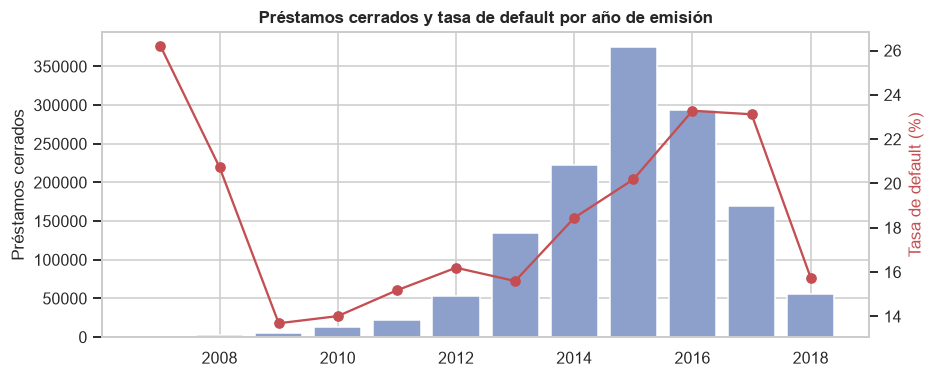

issue_year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
prestamos,603.0,2393.00,5281.00,12537.00,21721.00,53367.0,134804.0,223102.00,375545.00,293095.00,169300.00,56311.00
tasa_default,26.2,20.73,13.69,14.01,15.18,16.2,15.6,18.45,20.18,23.28,23.12,15.75


In [14]:
cohortes = df.groupby("issue_year").agg(prestamos=("default", "size"), tasa_default=("default", "mean"))
fig, ax1 = plt.subplots(figsize=(9, 3.6))
ax1.bar(cohortes.index, cohortes["prestamos"], color="#8DA0CB")
ax1.set_ylabel("Préstamos cerrados")
ax2 = ax1.twinx()
ax2.plot(cohortes.index, 100 * cohortes["tasa_default"], color="#C44E52", marker="o")
ax2.set_ylabel("Tasa de default (%)", color="#C44E52")
ax2.grid(False)
ax1.set_title("Préstamos cerrados y tasa de default por año de emisión")
u.guardar_fig(fig, "01_cohortes")
plt.show()
cohortes.assign(tasa_default=lambda d: (100 * d["tasa_default"]).round(2)).T

## 1.8 Lectura con Spark (comparación de tiempos)

Se lee el mismo CSV con Spark, con la configuración de sesión exigida en la sección 9.10.4.5.
Todas las columnas se leen como texto (sin `inferSchema`, que obligaría a recorrer el archivo dos
veces); el conteo de filas fuerza la lectura completa.

In [15]:
import spark_utils as su

spark = su.sesion_spark()
t0 = time.time()
sdf = su.leer_csv(spark)
n_spark = sdf.count()
t_spark = time.time() - t0
print(f"Tiempo de lectura + conteo con Spark: {t_spark:.1f} s ({n_spark:,} filas)")
print(f"Tiempo de lectura con pandas: {t_pandas:.1f} s")
print("Particiones del DataFrame leído:", sdf.rdd.getNumPartitions())

Tiempo de lectura + conteo con Spark: 7.3 s (2,260,701 filas)
Tiempo de lectura con pandas: 26.9 s
Particiones del DataFrame leído: 1


Spark obtiene el mismo número de filas que pandas (2.260.701). Su tiempo es menor porque el
conteo no necesita convertir los 151 campos de cada fila en objetos de Python: el lector de CSV
de Spark solo analiza los delimitadores. pandas, en cambio, construye un DataFrame de 6,3 GB en
memoria. El archivo `.gz` no es divisible, así que Spark lo lee en **una sola partición** con un
único núcleo: en esta etapa no aprovecha el paralelismo. La ventaja de Spark aparece cuando los
datos ya están particionados y en caché (capítulo 7).

In [16]:
u.guardar_json({"pandas_lectura_s": t_pandas, "spark_lectura_conteo_s": t_spark,
                "filas_csv": int(n_spark)}, u.RESULTADOS / "tiempos_carga.json")
spark.stop()

## 1.9 Almacenamiento intermedio

Se guarda el conjunto de préstamos cerrados, con todas sus columnas, en formato Parquet para los
capítulos de EDA. El modelado con Spark no usa este archivo: vuelve a leer el CSV original.

In [17]:
df.to_parquet(u.PRESTAMOS, index=False)
print(f"Guardado {u.PRESTAMOS.name}: {len(df):,} filas x {df.shape[1]} columnas, "
      f"{u.PRESTAMOS.stat().st_size / 2**20:.0f} MB")
print(f"Tasa global de default: {100 * df['default'].mean():.2f} %")

Guardado prestamos_cerrados.parquet: 1,348,059 filas x 154 columnas, 196 MB
Tasa global de default: 19.98 %
